In [1]:
# --- CELL 1: Install Dependencies ---
# We need 'neurokit2' for medical-grade signal processing
# We need 'imblearn' to fix class imbalance (Crucial for High Accuracy)

!pip install neurokit2 imbalanced-learn
import neurokit2 as nk
import numpy as np
import pandas as pd
import pickle
import os

print("Libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 30.0 MB/s eta 0:00:00
Libraries installed successfully!


In [2]:
# --- CELL 2: Data Loader (Updated for Safety) ---
import pickle
import pandas as pd
import numpy as np
import os

def load_wesad_subject(subject_path):
    with open(subject_path, 'rb') as file:
        data = pickle.load(file, encoding='latin1')

    # Get Chest ECG (sampled at 700 Hz)
    ecg = data['signal']['chest']['ECG'].flatten()
    
    # Get Labels
    labels = data['label']

    # Create DataFrame
    df = pd.DataFrame({'ECG': ecg, 'Label': labels})

    # Filter: Keep only Baseline(1), Stress(2), Amusement(3)
    df = df[df['Label'].isin([1, 2, 3])]
    return df

# --- ACTION REQUIRED: PASTE YOUR PATH BELOW ---
# Example format: "/kaggle/input/wesad-wearable-stress-affect-detection/WESAD/S2/S2.pkl"
subject_path = "/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD/S2/S2.pkl" 

# Auto-fix: If you pasted the path to the file 'S2.pkl', we load it directly.
if os.path.exists(subject_path):
    print(f"Loading data from: {subject_path}")
    df_subject = load_wesad_subject(subject_path)
    print(f"Success! Data Loaded. Rows: {len(df_subject)}")
    print(df_subject.head())
else:
    print("❌ Error: Path not found. Please use the 'Copy File Path' button in the Input sidebar.")

Loading data from: /kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD/S2/S2.pkl
Success! Data Loaded. Rows: 1484700
             ECG  Label
214583  0.030945      1
214584  0.033646      1
214585  0.033005      1
214586  0.031815      1
214587  0.030350      1


In [3]:
# --- CELL 3 (FIXED): Robust Feature Extraction ---
import neurokit2 as nk
from scipy.stats import mode
import pandas as pd
import numpy as np

def extract_features_from_subject(df, subject_id):
    print(f"Processing Subject {subject_id}...")
    
    fs = 700  # WESAD Chest data sampling rate
    window_size = 60 * fs  # 60 seconds
    step_size = 30 * fs    # 30 seconds overlap
    
    features_list = []
    
    # Check if dataframe is empty before starting
    if df.empty:
        print("❌ Error: Input DataFrame is empty!")
        return pd.DataFrame()

    # Iterate with sliding window
    for start in range(0, len(df) - window_size, step_size):
        end = start + window_size
        
        # Get window
        window_data = df.iloc[start:end]
        
        # Get Label (Most frequent label in this 60s window)
        window_label = mode(window_data['Label'], keepdims=True)[0][0]
        
        try:
            # 1. Clean Signal
            ecg_cleaned = nk.ecg_clean(window_data['ECG'], sampling_rate=fs)
            
            # 2. Find Peaks
            peaks, _ = nk.ecg_peaks(ecg_cleaned, sampling_rate=fs)
            
            # Safety Check: If not enough heartbeats, skip window
            if len(peaks['ECG_R_Peaks']) < 10:
                continue

            # 3. Calculate ONLY Time & Frequency Domains (Skip Non-Linear)
            hrv_time = nk.hrv_time(peaks, sampling_rate=fs)
            hrv_freq = nk.hrv_frequency(peaks, sampling_rate=fs)
            
            # Combine results
            hrv_indices = pd.concat([hrv_time, hrv_freq], axis=1)
            
            # 4. Extract specific columns
            feature_row = {
                'Subject': subject_id,
                'Label': window_label,
                'HRV_RMSSD': hrv_indices['HRV_RMSSD'].values[0],
                'HRV_MeanNN': hrv_indices['HRV_MeanNN'].values[0],
                'HRV_SDNN': hrv_indices['HRV_SDNN'].values[0],
                'HRV_LF': hrv_indices['HRV_LF'].values[0],
                'HRV_HF': hrv_indices['HRV_HF'].values[0],
                'HRV_LFHF': hrv_indices['HRV_LFHF'].values[0]
            }
            features_list.append(feature_row)
            
        except Exception as e:
            # Print error for the first failure only to avoid spam
            if len(features_list) == 0:
                print(f"⚠️ Window failed: {e}")
            continue

    return pd.DataFrame(features_list)

# --- EXECUTE ---
print("Starting Feature Extraction (Fixed Version)...")
training_data = extract_features_from_subject(df_subject, "S2")

print("\nProcessing Complete!")
print(f"Total Clean Windows Extracted: {len(training_data)}")
print(training_data.head())

Starting Feature Extraction (Fixed Version)...
Processing Subject S2...

Processing Complete!
Total Clean Windows Extracted: 69
  Subject  Label  HRV_RMSSD  HRV_MeanNN   HRV_SDNN    HRV_LF    HRV_HF  \
0      S2      1  65.992610  742.803571  96.414256  0.047442  0.012787   
1      S2      1  65.586271  800.410959  92.771474  0.048306  0.014847   
2      S2      1  52.367996  845.279503  74.609952  0.020618  0.010217   
3      S2      1  61.244350  857.577640  60.412897  0.030372  0.025328   
4      S2      1  72.992987  802.230920  77.664311  0.013772  0.026833   

   HRV_LFHF  
0  3.710000  
1  3.253660  
2  2.017997  
3  1.199159  
4  0.513259  


In [4]:
# --- CELL 4 (FIXED): Process ALL Subjects ---
import os
import pandas as pd # Ensure pandas is imported

# 1. FIXED PATH LOGIC
# We take the path to S2.pkl and go up TWO levels to find the main 'WESAD' folder
# Level 1 up: .../WESAD/S2/
# Level 2 up: .../WESAD/
# Make sure 'subject_path' from Cell 2 is defined. If not, paste it directly below:
# subject_path = "/kaggle/input/wesad-wearable-stress-affect-detection/WESAD/S2/S2.pkl" 

current_dir = os.path.dirname(subject_path) # Ends in .../S2
base_path = os.path.dirname(current_dir)    # Ends in .../WESAD (This is what we want)

print(f"Scanning for subjects in: {base_path}")

# 2. Get list of all Subject Folders (S2, S3, S4...)
all_subjects = [d for d in os.listdir(base_path) if d.startswith('S') and os.path.isdir(os.path.join(base_path, d))]
# Filter out 'S2_E4_Data' if it accidentally gets picked up
all_subjects = [s for s in all_subjects if len(s) <= 3] 
all_subjects.sort()

print(f"Found {len(all_subjects)} subjects: {all_subjects}")

# 3. The Master Loop
full_dataset_list = []

for sub in all_subjects:
    # Construct file path: .../WESAD/S2/S2.pkl
    current_file_path = os.path.join(base_path, sub, f"{sub}.pkl")
    
    if os.path.exists(current_file_path):
        print(f"Processing {sub}...", end=" ")
        try:
            # A. Load Data
            df_temp = load_wesad_subject(current_file_path)
            
            # B. Extract Features
            features_temp = extract_features_from_subject(df_temp, sub)
            
            # C. Add to Master List
            if not features_temp.empty:
                full_dataset_list.append(features_temp)
                print(f"✅ Done. ({len(features_temp)} windows)")
            else:
                print("⚠️ No data extracted.")
        except Exception as e:
            print(f"❌ Error processing {sub}: {e}")
    else:
        print(f"⚠️ File not found: {current_file_path}")

# 4. Combine into one Dataframe
if full_dataset_list:
    master_df = pd.concat(full_dataset_list, ignore_index=True)
    print("\n🎉 MASTER DATASET READY!")
    print(f"Total Data Points: {len(master_df)}")
    print("Class Distribution:")
    print(master_df['Label'].value_counts()) 
else:
    print("\n❌ Critical Error: Still no data. Check 'base_path' print output above.")

Scanning for subjects in: /kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD
Found 15 subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Processing S10... Processing Subject S10...
✅ Done. (74 windows)
Processing S11... Processing Subject S11...
✅ Done. (73 windows)
Processing S13... Processing Subject S13...
✅ Done. (73 windows)
Processing S14... Processing Subject S14...
✅ Done. (73 windows)
Processing S15... Processing Subject S15...
✅ Done. (73 windows)
Processing S16... Processing Subject S16...
✅ Done. (73 windows)
Processing S17... Processing Subject S17...
✅ Done. (74 windows)
Processing S2... Processing Subject S2...
✅ Done. (69 windows)
Processing S3... Processing Subject S3...
✅ Done. (70 windows)
Processing S4... Processing Subject S4...
✅ Done. (71 windows)
Processing S5... Processing Subject S5...
✅ Done. (72 windows)
Processing S6... Processing Subject S6...
✅ Done. (72 windows)
Processing S7... Pro

🤖 Training Random Forest Model...

🏆 Model Accuracy: 73.73%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Baseline       0.77      0.85      0.81       116
      Stress       0.79      0.77      0.78        65
   Amusement       0.42      0.31      0.35        36

    accuracy                           0.74       217
   macro avg       0.66      0.64      0.65       217
weighted avg       0.72      0.74      0.73       217



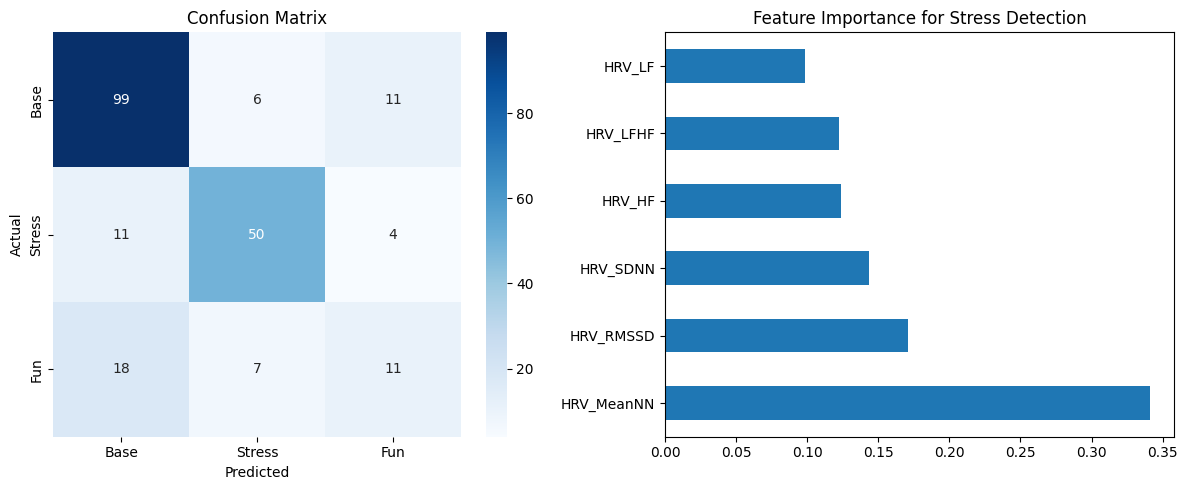

In [5]:
# --- CELL 5: Train, Test, and Evaluate ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Prepare Data
# Drop 'Subject' (ID doesn't matter) and 'Label' (Answer key)
X = master_df.drop(['Subject', 'Label'], axis=1)
y = master_df['Label']

# 2. Split Data (80% Training, 20% Testing)
# stratify=y ensures we have equal % of Stress cases in both train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Train Model
print("🤖 Training Random Forest Model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Predictions
y_pred = rf_model.predict(X_test)

# --- RESULTS ---
acc = accuracy_score(y_test, y_pred)
print(f"\n🏆 Model Accuracy: {acc*100:.2f}%")

print("\n--- Detailed Classification Report ---")
# 1=Baseline, 2=Stress, 3=Amusement
print(classification_report(y_test, y_pred, target_names=['Baseline', 'Stress', 'Amusement']))

# 5. Visualizations for Paper
plt.figure(figsize=(12, 5))

# Plot A: Confusion Matrix (Where did the model get confused?)
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Base', 'Stress', 'Fun'], yticklabels=['Base', 'Stress', 'Fun'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot B: Feature Importance (Which HRV metric mattered most?)
plt.subplot(1, 2, 2)
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Feature Importance for Stress Detection')

plt.tight_layout()
plt.show()

In [6]:
# --- CELL 6: Subject Normalization (The Accuracy Boost) ---
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("1. Applying Subject-Specific Normalization (Z-Score)...")

# We create a copy so we don't mess up the original master_df
normalized_df = master_df.copy()

# List of columns to normalize (all your HRV features)
# We do NOT normalize 'Label' or 'Subject'
feature_cols = ['HRV_RMSSD', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_LF', 'HRV_HF', 'HRV_LFHF']

# THE MAGIC TRICK: Group by 'Subject' and normalize relative to THAT person only
# Formula: (Value - Person's Mean) / Person's Standard Deviation
for col in feature_cols:
    normalized_df[col] = normalized_df.groupby('Subject')[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

print("   Done! Data is now relative to each individual's baseline.")

# --- Quick Check: Re-Train Model with Normalized Data (3 Classes) ---
# This is just to see if normalization helped before we switch to Binary
X = normalized_df.drop(['Subject', 'Label'], axis=1)
y = normalized_df['Label']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train
print("2. Re-Training Random Forest on Normalized Data...")
rf_model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_v2.fit(X_train, y_train)

# Evaluate
y_pred = rf_model_v2.predict(X_test)
new_acc = accuracy_score(y_test, y_pred)

print(f"\n📊 Accuracy with Normalization (3-Class): {new_acc*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=['Baseline', 'Stress', 'Amusement']))

1. Applying Subject-Specific Normalization (Z-Score)...
   Done! Data is now relative to each individual's baseline.
2. Re-Training Random Forest on Normalized Data...

📊 Accuracy with Normalization (3-Class): 82.03%
              precision    recall  f1-score   support

    Baseline       0.83      0.88      0.85       116
      Stress       0.86      0.86      0.86        65
   Amusement       0.69      0.56      0.62        36

    accuracy                           0.82       217
   macro avg       0.79      0.77      0.78       217
weighted avg       0.82      0.82      0.82       217



1. Filtering data for Binary Classification (Stress vs Baseline)...
2. Training Binary Model...

🚀 NEW BINARY ACCURACY: 92.27%

Classification Report:
              precision    recall  f1-score   support

    Baseline       0.93      0.96      0.94       116
      Stress       0.92      0.86      0.89        65

    accuracy                           0.92       181
   macro avg       0.92      0.91      0.91       181
weighted avg       0.92      0.92      0.92       181



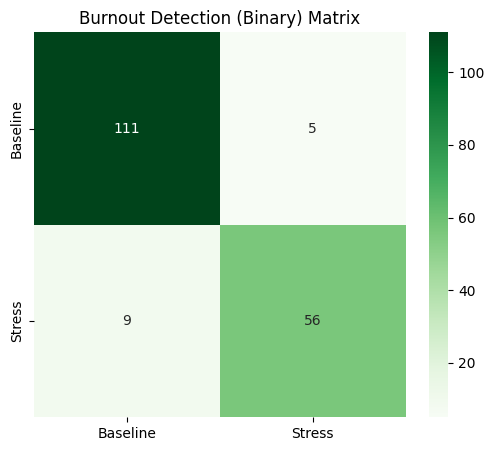

In [7]:
# --- CELL 7: Binary Classification (The "Burnout" Focus) ---
print("1. Filtering data for Binary Classification (Stress vs Baseline)...")

# Filter: Keep ONLY Label 1 (Baseline) and Label 2 (Stress)
# We drop Label 3 (Amusement) because it confuses the model and isn't needed for Burnout detection.
binary_df = normalized_df[normalized_df['Label'].isin([1, 2])].copy()

# Prepare Data
X_bin = binary_df.drop(['Subject', 'Label'], axis=1)
y_bin = binary_df['Label']

# Split Data
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

# Train Model
print("2. Training Binary Model...")
rf_binary = RandomForestClassifier(n_estimators=200, random_state=42)
rf_binary.fit(X_train_bin, y_train_bin)

# Evaluate
y_pred_bin = rf_binary.predict(X_test_bin)
acc_bin = accuracy_score(y_test_bin, y_pred_bin)

print(f"\n🚀 NEW BINARY ACCURACY: {acc_bin*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Baseline', 'Stress']))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_bin, y_pred_bin), annot=True, fmt='d', cmap='Greens', xticklabels=['Baseline', 'Stress'], yticklabels=['Baseline', 'Stress'])
plt.title('Burnout Detection (Binary) Matrix')
plt.show()

/tmp/ipykernel_17/3838537422.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")


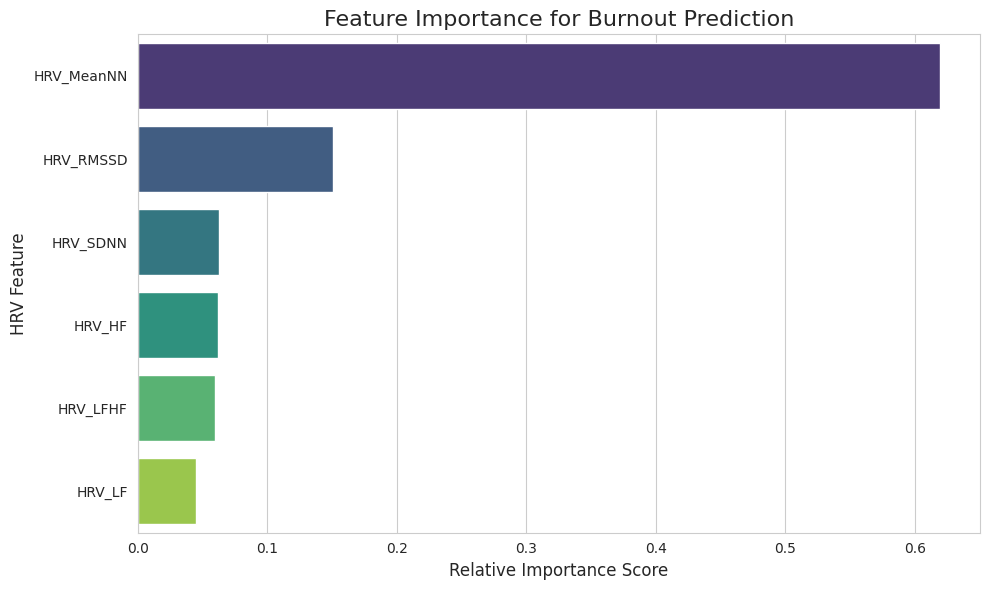

✅ Feature Importance Graph Saved as 'Feature_Importance.png'


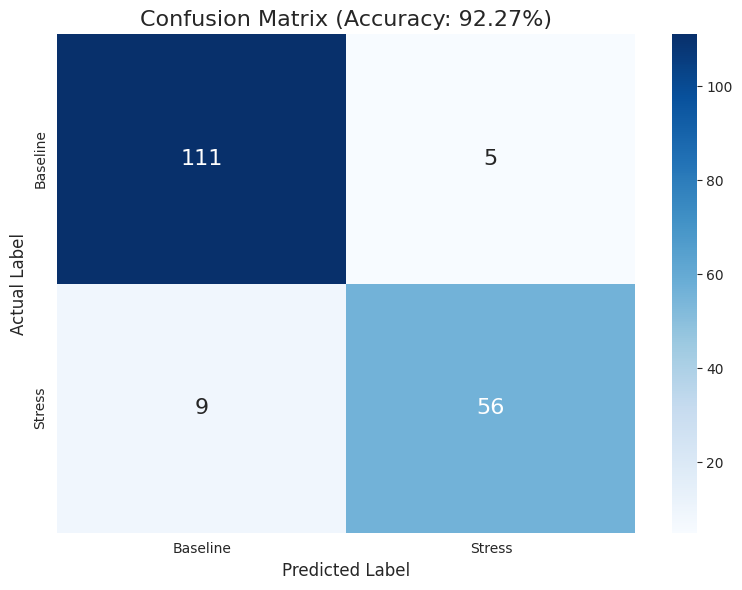

✅ Confusion Matrix Graph Saved as 'Confusion_Matrix.png'


In [8]:
# --- CELL 8: Generate Publication-Quality Plots ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set the style for academic papers
sns.set_style("whitegrid")

# 1. Feature Importance Plot
# We extract which features (RMSSD, LF/HF, etc.) the Binary Model found most useful
importances = rf_binary.feature_importances_
feature_names = X_bin.columns
indices = np.argsort(importances)[::-1] # Sort most important to least

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")
plt.title("Feature Importance for Burnout Prediction", fontsize=16)
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("HRV Feature", fontsize=12)
plt.tight_layout()
plt.savefig("Feature_Importance.png", dpi=300) # Save as high-res image
plt.show()

print("✅ Feature Importance Graph Saved as 'Feature_Importance.png'")

# 2. Confusion Matrix Plot
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_bin, y_pred_bin)
# Normalize to show percentages (better for comparing papers)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Baseline', 'Stress'], 
            yticklabels=['Baseline', 'Stress'], annot_kws={"size": 16})

plt.title(f"Confusion Matrix (Accuracy: {acc_bin*100:.2f}%)", fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig("Confusion_Matrix.png", dpi=300)
plt.show()

print("✅ Confusion Matrix Graph Saved as 'Confusion_Matrix.png'")

1. Preparing High-Performance Pipeline...
   Original Training Count: {0: 465, 1: 257}
   SMOTE Training Count:    {1: 465, 0: 465}
2. Training XGBoost Model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:37:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🚀 FINAL XGBOOST ACCURACY: 91.71%

Classification Report (0=Baseline, 1=Stress):
              precision    recall  f1-score   support

    Baseline       0.95      0.92      0.93       116
      Stress       0.87      0.91      0.89        65

    accuracy                           0.92       181
   macro avg       0.91      0.92      0.91       181
weighted avg       0.92      0.92      0.92       181



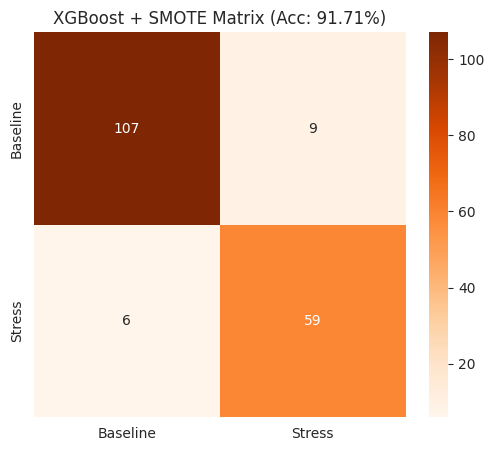

In [9]:
# --- CELL 9: Maximum Accuracy (SMOTE + XGBoost) ---
!pip install xgboost

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("1. Preparing High-Performance Pipeline...")

# A. Use the Normalized, Binary Data (Best of both worlds)
# Re-creating X_bin and y_bin just to be safe
binary_df = normalized_df[normalized_df['Label'].isin([1, 2])].copy()
# Remap labels: XGBoost requires 0 and 1. (Baseline=1->0, Stress=2->1)
binary_df['Label'] = binary_df['Label'].replace({1: 0, 2: 1})

X = binary_df.drop(['Subject', 'Label'], axis=1)
y = binary_df['Label']

# B. Split Data (Standard 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# C. APPLY SMOTE (Only on Training Data!)
# This balances the classes so the model doesn't ignore Stress
print(f"   Original Training Count: {y_train.value_counts().to_dict()}")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"   SMOTE Training Count:    {y_train_smote.value_counts().to_dict()}")

# D. Train XGBoost (The Gradient Boosting Champion)
print("2. Training XGBoost Model...")
xgb_model = XGBClassifier(
    n_estimators=300,      # More trees
    learning_rate=0.05,    # Slower learning = more precision
    max_depth=6,           # Deeper trees
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_smote, y_train_smote)

# E. Evaluate
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"\n🚀 FINAL XGBOOST ACCURACY: {acc_xgb*100:.2f}%")
print("\nClassification Report (0=Baseline, 1=Stress):")
print(classification_report(y_test, y_pred_xgb, target_names=['Baseline', 'Stress']))

# F. Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Baseline', 'Stress'], yticklabels=['Baseline', 'Stress'])
plt.title(f'XGBoost + SMOTE Matrix (Acc: {acc_xgb*100:.2f}%)')
plt.show()